# paper_figure_exsupp.ipynb — Extended supplementary analysis

## scVI-integrated human colon scRNA atlas (Burclaff + Smillie)

Burclaff 2022 enriches the **epithelial** compartment, Smillie 2019
enriches the **immune** compartment. Their `.X` matrices are at different
processing stages (Burclaff: scaled; Smillie: log-normalised), so the
previous Harmony-on-scaled-PCA run could not properly model the cross-source
biology and the marker-density panels showed spurious overlap between the
epi and myeloid maps.

**Fix:** both source h5ads carry raw integer UMI counts in `.raw.X`.
We extract those, concatenate, store them in `adata.layers['counts']`,
log-normalise into `.X` for downstream display, then run **scVI**
(`ov.single.batch_correction(methods='scVI', n_layers=2, n_latent=30)`)
on the counts layer with `source` as the batch key. scVI's count-based
generative model handles the cross-protocol shifts properly.

UMAP is built from the scVI latent (`X_scVI`) so epi vs myeloid clusters
mix cells from both sources and AD-gene-density panels show real
biological co-occurrence instead of dataset-specific artefacts.

Environment: conda `omicdev` (omicverse 2.2.x + scvi-tools 1.3 + GPU).

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import sparse, stats
warnings.filterwarnings('ignore')
%matplotlib inline

BASE = '..'
RES  = os.path.join(BASE, 'results')
DATA = os.path.join(BASE, 'data')
FIG  = os.path.join(BASE, 'figures')
os.makedirs(FIG, exist_ok=True)

import scanpy as sc
import omicverse as ov
import anndata as ad

ov.style()
LEGEND_FS, TICK_FS, LABEL_FS, TITLE_FS, TEXT_FS = 11, 12, 13, 13, 11

def save_panel(fig, name, dpi=300):
    for ext in ('pdf','png','svg'):
        fig.savefig(os.path.join(FIG, f'{name}.{ext}'), bbox_inches='tight', dpi=dpi)
    print(f'  saved -> {name}.{{pdf,png,svg}}')

print('setup OK')

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

setup OK


## 1. Load + concatenate Burclaff (epi) + Smillie (immune)

In [2]:
# Paths to source h5ads (data/gut_atlas/ is symlinked → 26_gsmap/data/gut_atlas)
BURCLAFF_H5 = f'{DATA}/gut_atlas/Burclaff2022_colon_epi.h5ad'
SMILLIE_H5  = f'{DATA}/gut_atlas/Smillie2019_colon.h5ad'

AD     = ['PICALM','CD2AP','ADAM10','CR1','APP','SORL1','PSEN1']
EPI    = ['EPCAM','KRT8','MUC2','VIL1']
MYE    = ['CD68','CD163','CD14','AIF1','LYZ','C1QA','C1QB','TYROBP']
FOCAL  = AD + EPI + MYE

def load_raw(path, source_label):
    a = sc.read_h5ad(path)
    # Extract raw integer counts and use as .X
    a_raw = a.raw.to_adata() if a.raw is not None else a
    # Rename Ensembl → symbols using the source's feature_name col
    if 'feature_name' in a_raw.var.columns:
        a_raw.var['symbol'] = a_raw.var['feature_name'].astype(str).values
        a_raw.var_names = a_raw.var['symbol'].astype(str).values
    elif 'feature_name' in a.var.columns:
        # try mapping by Ensembl ID intersect
        sym = a.var.set_index(a.var_names)['feature_name'].astype(str)
        common = a_raw.var_names.intersection(sym.index)
        a_raw = a_raw[:, common].copy()
        a_raw.var_names = sym.loc[common].values
    a_raw.var_names_make_unique()
    a_raw.obs['source'] = source_label
    if 'cell_type' in a.obs.columns:
        a_raw.obs['cell_type_source'] = a.obs['cell_type'].astype(str).values
    return a_raw

burclaff = load_raw(BURCLAFF_H5, 'Burclaff2022_epi')
smillie  = load_raw(SMILLIE_H5,  'Smillie2019_immune')
print(f'Burclaff (raw counts): {burclaff.shape}')
print(f'Smillie  (raw counts): {smillie.shape}')

# Sanity check counts are integer-valued
import numpy as np
def check_counts(a, name):
    x = a[:50, :10].X
    if sparse.issparse(x): x = x.toarray()
    x = np.asarray(x)
    print(f'  {name}: max={x.max():.1f}, '
          f'fraction integer={(x == x.astype(int)).mean():.3f}')
check_counts(burclaff, 'Burclaff')
check_counts(smillie,  'Smillie')

Burclaff (raw counts): (12590, 22624)
Smillie  (raw counts): (41650, 18753)
  Burclaff: max=7.0, fraction integer=1.000
  Smillie: max=6.0, fraction integer=1.000


In [3]:
# Subsample Smillie to ~15k cells (stratified by cell_type) so it doesn't drown Burclaff
np.random.seed(42)
ct_s = smillie.obs['cell_type_source'].astype(str).values
keep_idx = []
for c in np.unique(ct_s):
    idx = np.where(ct_s == c)[0]
    n = min(len(idx), max(200, int(15000 * len(idx) / len(ct_s))))
    keep_idx.extend(np.random.choice(idx, n, replace=False))
smillie_sub = smillie[keep_idx].copy()
print(f'Smillie subsampled: {smillie_sub.shape[0]:,} cells')

merged = ad.concat([burclaff, smillie_sub], join='inner', label='dataset',
                   keys=['Burclaff','Smillie'], index_unique='_')
merged.obs['source'] = merged.obs['dataset'].astype(str)
print(f'Merged: {merged.shape}')
print(f'  source split: {merged.obs["source"].value_counts().to_dict()}')
print(f'  common gene symbols: {merged.n_vars:,}')

# Store counts in layers, then normalise + log1p into .X
merged.layers['counts'] = merged.X.copy()
sc.pp.normalize_total(merged, target_sum=1e4)
sc.pp.log1p(merged)
print('Done: counts in .layers["counts"], log-norm in .X')

Smillie subsampled: 15,464 cells

Merged: (28054, 16322)
  source split: {'Smillie': 15464, 'Burclaff': 12590}
  common gene symbols: 16,322


Done: counts in .layers["counts"], log-norm in .X


## 2. Preprocess + Harmony batch correction

Source-level batch effect is the dominant signal of separation between
the two cohorts (different protocols + different selection compartment).
Harmony aligns the two clouds in PCA space, so the resulting UMAP shows
biological cell-type structure rather than donor source.

In [4]:
# Pick highly-variable genes for scVI (uses counts layer)
sc.pp.highly_variable_genes(merged, n_top_genes=3000, flavor='seurat_v3',
                            layer='counts', batch_key='source', subset=False)
print(f'HVG: {int(merged.var["highly_variable"].sum())} / {merged.n_vars}')
# Ensure FOCAL genes are kept even if not HVG (so we can plot them later)
merged.var['highly_variable'] = merged.var['highly_variable'] | merged.var_names.isin(FOCAL)
print(f'after forcing FOCAL: HVG = {int(merged.var["highly_variable"].sum())}')

HVG: 3000 / 16322
after forcing FOCAL: HVG = 3007


In [5]:
# Subset to HVG and run scVI on counts layer (GPU)
hvg_adata = merged[:, merged.var['highly_variable']].copy()
# scVI needs the counts in .X (or specify layer)
hvg_adata.layers['counts'] = hvg_adata.layers['counts']  # keep
ov.single.batch_correction(
    hvg_adata,
    batch_key='source',
    methods='scVI',
    n_layers=2,
    n_latent=30,
    max_epochs=100,
)
# Copy the scVI latent back to merged for downstream plotting on full gene set
merged.obsm['X_scVI'] = hvg_adata.obsm['X_scVI']
print('scVI done; latent shape:', merged.obsm['X_scVI'].shape)

...Begin using scVI to correct batch effect


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


You are using a CUDA device ('NVIDIA H100 80GB HBM3') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.



╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 130.4805s                                               │
│  Shape:    28,054 x 3,007 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ _scvi_batch (int)                                    │
│           │ ✚ _scvi_labels (int)                                   │
│                                                                    │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ _scvi_manager_uuid                                   │
│           │ ✚ _scvi_uuid                                           │
│                                                                    │
│  ● 

In [6]:
# Build UMAP from scVI latent
sc.pp.neighbors(merged, use_rep='X_scVI', n_neighbors=15)
sc.tl.umap(merged, min_dist=0.3)
sc.tl.leiden(merged, resolution=0.5, key_added='leiden')
print('UMAP done. Leiden clusters:', merged.obs['leiden'].nunique())

UMAP done. Leiden clusters: 28


## 3. Visualise — source mixing, cellType, AD candidates, markers

  saved -> FigEx_burclaff_smillie_scvi_categorical.{pdf,png,svg}


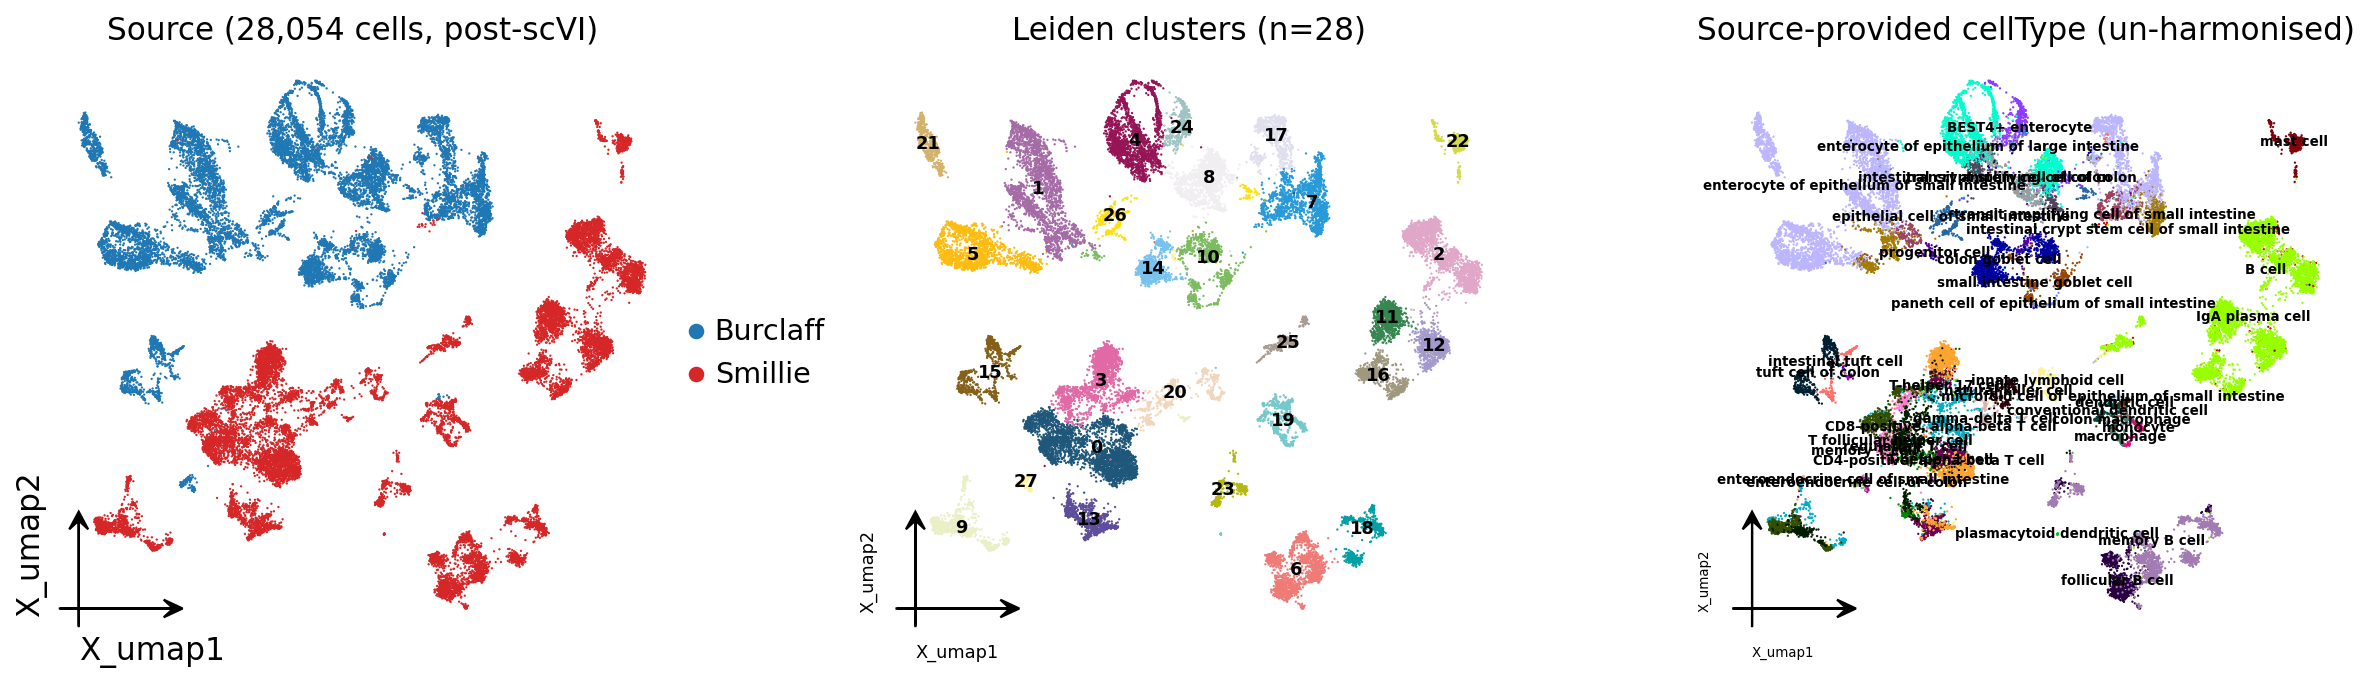

In [7]:
# 3-panel categorical UMAP: source / leiden / cell_type_source
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ov.pl.embedding(merged, basis='X_umap', color='source',
                show=False, ax=axes[0], frameon='small',
                title=f'Source ({merged.n_obs:,} cells, post-scVI)',
                palette=['#1f77b4','#d62728'])
ov.pl.embedding(merged, basis='X_umap', color='leiden',
                show=False, ax=axes[1], frameon='small',
                title=f'Leiden clusters (n={merged.obs["leiden"].nunique()})',
                legend_loc='on data', legend_fontsize=8)
ov.pl.embedding(merged, basis='X_umap', color='cell_type_source',
                show=False, ax=axes[2], frameon='small',
                title='Source-provided cellType (un-harmonised)',
                legend_loc='on data', legend_fontsize=6)
plt.tight_layout()
save_panel(fig, 'FigEx_burclaff_smillie_scvi_categorical')
plt.show()

✅ density_PICALM written (train cells = 7136)


✅ density_CD2AP written (train cells = 9481)


✅ density_ADAM10 written (train cells = 7571)


✅ density_CR1 written (train cells = 537)


✅ density_APP written (train cells = 11288)


...

✅ density_CD14 written (train cells = 1243)


✅ density_AIF1 written (train cells = 1203)


✅ density_LYZ written (train cells = 3678)


✅ density_TYROBP written (train cells = 1694)


  saved -> FigEx_burclaff_smillie_scvi_genes.{pdf,png,svg}


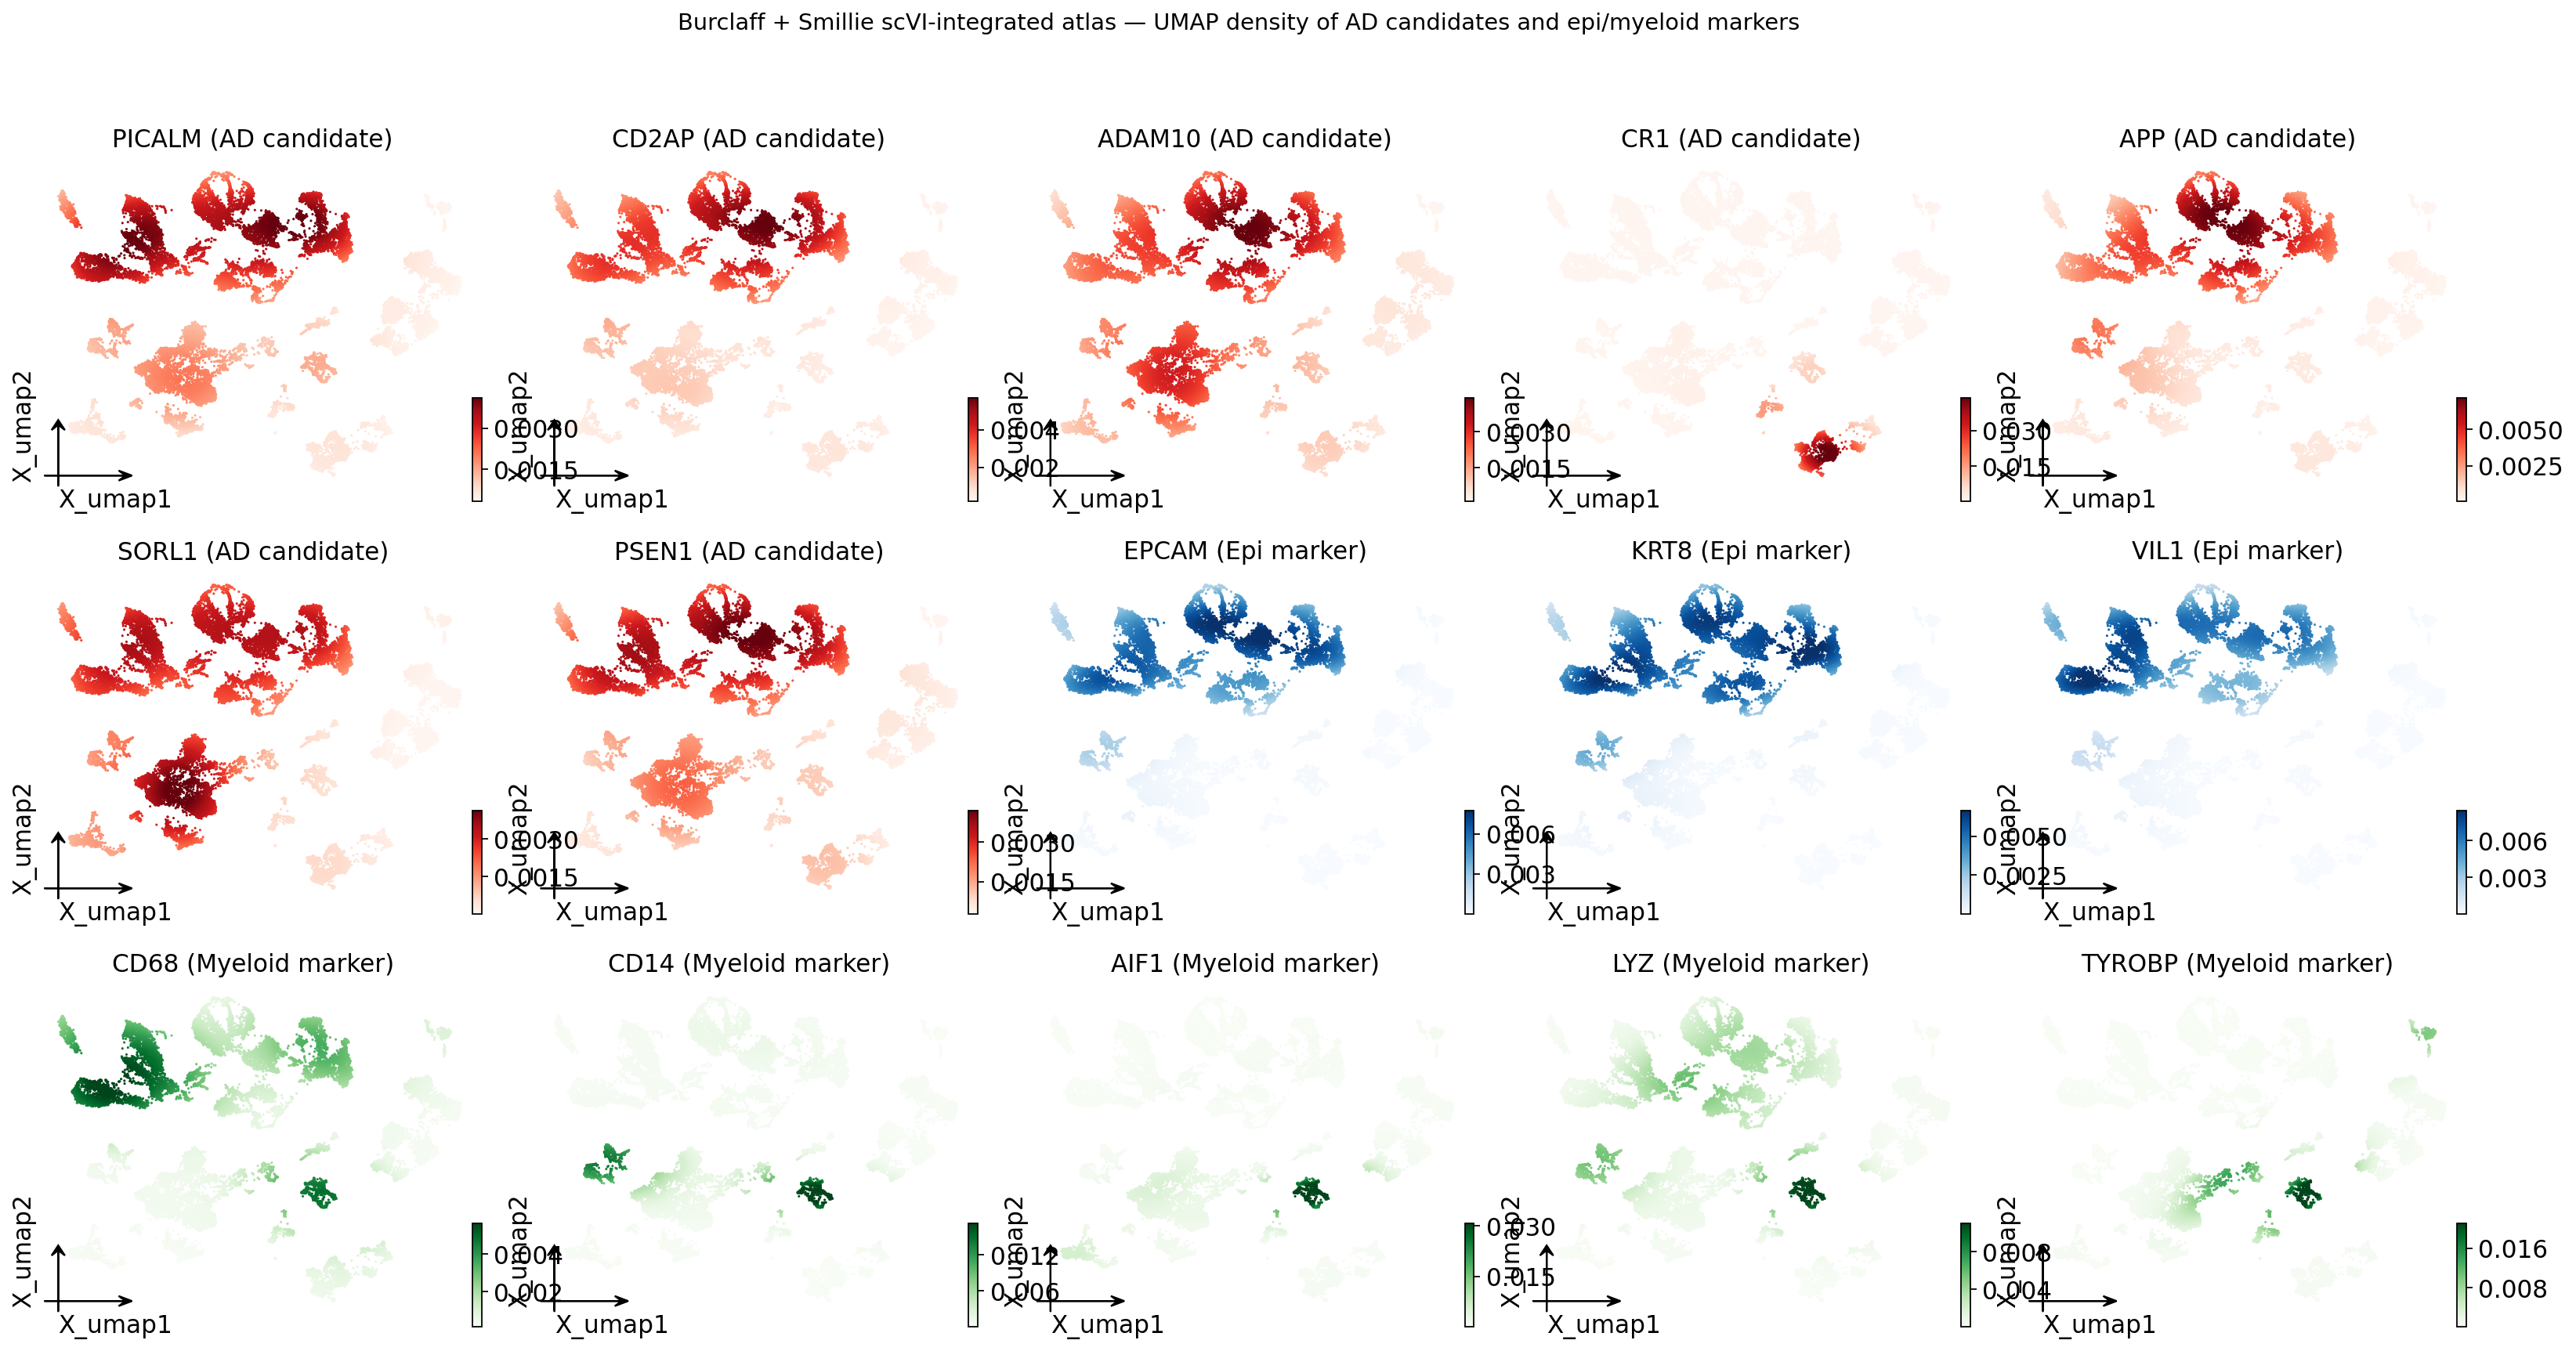

In [8]:
# Gene-density UMAP for AD candidates + epi markers + myeloid markers
gene_panels = [(g, 'Reds',   'AD candidate') for g in AD if g in merged.var_names]
gene_panels += [(g, 'Blues',  'Epi marker')   for g in EPI if g in merged.var_names]
gene_panels += [(g, 'Greens', 'Myeloid marker') for g in MYE if g in merged.var_names]

kde_ok = [g for g, *_ in gene_panels
          if (merged[:, g].X > 0.01).sum() >= 200]
ov.pl.calculate_gene_density(merged, features=kde_ok, basis='X_umap',
                              dims=(0, 1), adjust=0.4, min_expr=0.01)

ncol = 5
nrow = (len(gene_panels) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(4.0*ncol, 3.6*nrow))
axes_f = axes.flatten()
for i, (g, cmap, kind) in enumerate(gene_panels):
    ax = axes_f[i]
    dk = f'density_{g}'
    if dk not in merged.obs.columns:
        ax.text(0.5, 0.5, f'{g}\nno density', ha='center', va='center'); ax.axis('off'); continue
    ov.pl.embedding(merged, basis='X_umap', color=dk,
                    cmap=cmap, vmax='p99', sort_order=True, size=8,
                    ax=ax, show=False, frameon='small',
                    title=f'{g} ({kind})', colorbar_loc='right')
for j in range(len(gene_panels), nrow*ncol):
    axes_f[j].axis('off')

fig.suptitle('Burclaff + Smillie scVI-integrated atlas — UMAP density of '
             'AD candidates and epi/myeloid markers',
             fontsize=TITLE_FS, y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.97])
save_panel(fig, 'FigEx_burclaff_smillie_scvi_genes')
plt.show()

## 4. Quantify epi-vs-myeloid preference on the integrated atlas

With both compartments present in the same UMAP, we can now ask: for
each AD candidate gene, what is the Pearson correlation of its
expression with the epithelial score (mean of EPCAM/KRT8/MUC2/VIL1) vs
the myeloid score (mean of CD68/CD163/CD14/AIF1/LYZ/C1QA/C1QB/TYROBP)?
Positive epi-r and negative mye-r → epi-leaning; opposite → myeloid-leaning.

  gene  r_vs_epi  r_vs_mye   preference
PICALM     0.316     0.125  EPI-leaning
 CD2AP     0.502     0.037  EPI-leaning
ADAM10     0.220     0.070  EPI-leaning
   CR1    -0.114     0.046 mixed / weak
   APP     0.623     0.075  EPI-leaning
 SORL1     0.283     0.025  EPI-leaning
 PSEN1     0.243     0.056  EPI-leaning


  saved -> FigEx_burclaff_smillie_scvi_epi_vs_mye_preference.{pdf,png,svg}


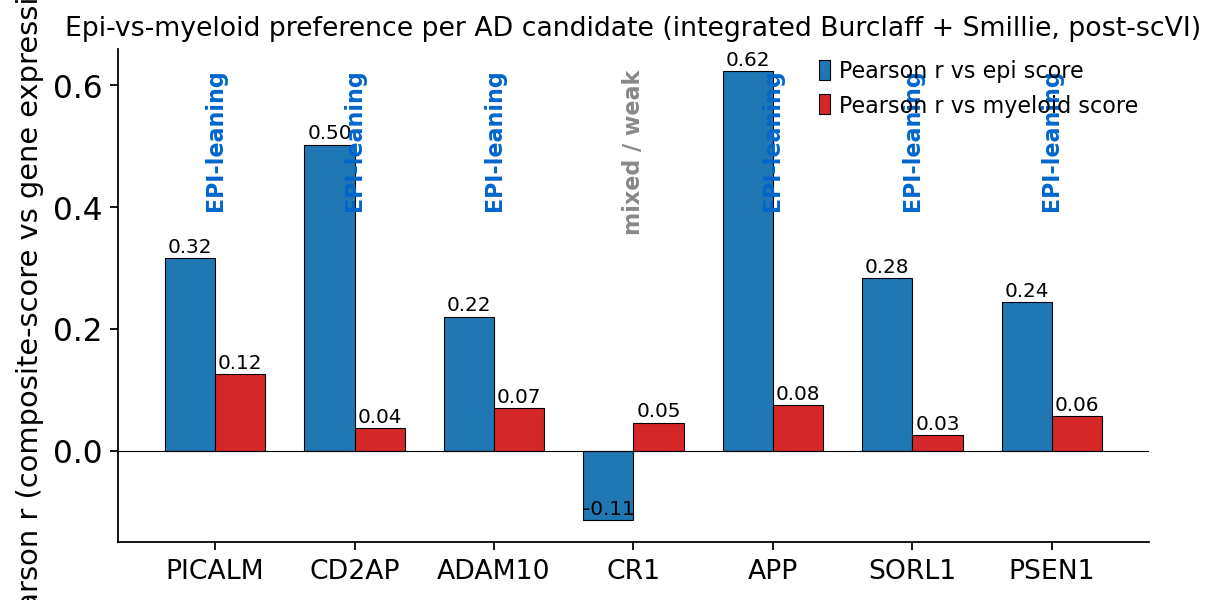

In [9]:
# Compute epi and myeloid composite scores per cell
X = merged.X
if sparse.issparse(X): X = X.toarray()
var = list(merged.var_names)
def mean_of(gene_list):
    cols = [var.index(g) for g in gene_list if g in var]
    return X[:, cols].mean(axis=1) if cols else np.zeros(merged.n_obs)
epi_score = mean_of(EPI)
mye_score = mean_of(MYE)
merged.obs['epi_score'] = epi_score
merged.obs['mye_score'] = mye_score

# Per-AD-gene Pearson r vs each compartment score
rows = []
for g in AD:
    if g not in merged.var_names:
        rows.append({'gene': g, 'r_vs_epi': np.nan, 'r_vs_mye': np.nan,
                     'preference': 'gene missing'}); continue
    v = X[:, var.index(g)]
    r_e = stats.pearsonr(v, epi_score)[0] if v.std() else np.nan
    r_m = stats.pearsonr(v, mye_score)[0] if v.std() else np.nan
    if np.isnan(r_e) or np.isnan(r_m):
        pref = 'undefined'
    elif r_e > 0.10 and r_e > r_m + 0.05:
        pref = 'EPI-leaning'
    elif r_m > 0.10 and r_m > r_e + 0.05:
        pref = 'MYE-leaning'
    else:
        pref = 'mixed / weak'
    rows.append({'gene': g, 'r_vs_epi': round(r_e, 3),
                 'r_vs_mye': round(r_m, 3), 'preference': pref})
pref_df = pd.DataFrame(rows)
print(pref_df.to_string(index=False))
pref_df.to_csv(f'{RES}/scvi_epi_vs_mye_preference.csv', index=False)

# Bar visual
import seaborn as sns
fig, ax = plt.subplots(figsize=(7.5, 4.0))
x = np.arange(len(pref_df)); w = 0.36
ax.bar(x - w/2, pref_df['r_vs_epi'], w, color='#1f77b4',
       edgecolor='black', lw=0.5, label='Pearson r vs epi score')
ax.bar(x + w/2, pref_df['r_vs_mye'], w, color='#d62728',
       edgecolor='black', lw=0.5, label='Pearson r vs myeloid score')
ax.axhline(0, color='black', lw=0.5)
for i, (e, m) in enumerate(zip(pref_df['r_vs_epi'], pref_df['r_vs_mye'])):
    if pd.notna(e): ax.text(i-w/2, e+0.01, f'{e:.2f}', ha='center', fontsize=TEXT_FS-2)
    if pd.notna(m): ax.text(i+w/2, m+0.01, f'{m:.2f}', ha='center', fontsize=TEXT_FS-2)
for i, p in enumerate(pref_df['preference']):
    color = ('#0066cc' if 'EPI' in p else '#cc0000' if 'MYE' in p else '#888')
    ax.text(i, ax.get_ylim()[1]*0.95, p, ha='center', va='top',
            fontsize=TEXT_FS-1, color=color, fontweight='bold', rotation=90)
ax.set_xticks(x); ax.set_xticklabels(pref_df['gene'], fontsize=TICK_FS)
ax.set_ylabel('Pearson r (composite-score vs gene expression)', fontsize=LABEL_FS)
ax.set_title('Epi-vs-myeloid preference per AD candidate '
             '(integrated Burclaff + Smillie, post-scVI)',
             fontsize=TITLE_FS-1)
ax.legend(loc='upper right', frameon=False, fontsize=LEGEND_FS-1)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
save_panel(fig, 'FigEx_burclaff_smillie_scvi_epi_vs_mye_preference')
plt.show()